## Overview
This notebook analyzes the North America AFI dataset for the period 1979-2025 and builds a series of maps for return levels, parameter estimates, and model diagnostics. The workflow starts by loading the NetCDF data, defines the spatial domain, and then visualizes how extremes change over time.

In [34]:
import os

In [35]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from copy import copy


In [36]:
from matplotlib import cm
import cmaps
import matplotlib as mpl
from matplotlib.colors import ListedColormap

In [37]:
import warnings
warnings.filterwarnings('ignore')

## Step 1: Read AFI netcdf file
The next cells load the AFI NetCDF file and extract the key variables used for the maps: return levels, location and scale parameters, shape parameter, and cross-validated diagnostic fields.

In [38]:
yearb=1979
yeare=2025
B=300

ifile=f'~/data/AFI/NorthAmerica_ij_glostLocsca_extremes_gev_CV_CI300_1979_2025.nc'

ds = xr.open_dataset(ifile)
rl = ds['rl']
location = ds['location']
scale = ds['scale']
shape = ds['shape']
pvalueL = ds['pvalueL']
pvalueS = ds['pvalueS']
AIC = ds['AIC']
BIC = ds['BIC']
location_q = ds['location_q']
scale_q = ds['scale_q']
rl_q = ds['rl_q']
Difflocation_q = ds['Difflocation_q']
Diffscale_q = ds['Diffscale_q']
Diffrl_q = ds['Diffrl_q']
CRPS_cv = ds['CRPS_cv']
DawSeb_cv = ds['DawSeb_cv']
SE_cv = ds['SE_cv']
KS_D_cv = ds['KS_D_cv']
KS_pvalue_cv = ds['KS_pvalue_cv']
CVM_D_cv = ds['CVM_D_cv']
CVM_pvalue_cv = ds['CVM_pvalue_cv']
#AIC_cv = ds['AIC_cv']
#BIC_cv = ds['BIC_cv']

Tlon = ds.lon.data
Tlat = ds.lat.data

return_periods = ds.return_periods.data

units = 'degree-days (°C)'

## Step 2: Define plotting settings

These settings set the map extents, return periods, and contour levels used throughout the figures below.


In [39]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [40]:
Tyears=[1979,1960,1970,1980,1990,2000,2010,2020,2025]
Tyears=[1979,2025]
AEP = [1/irp for irp in return_periods]

In [41]:
I_colors = ['green','yellow','red','pink']
cmapI = mcolors.LinearSegmentedColormap.from_list("my_gradient", I_colors)
cmapAr= 'coolwarm_r'
cmapA = 'coolwarm'

In [42]:
latN = 72
latS = 25
lonW = -155+360
lonE = -60+360

cLat = (latN + latS)/2
cLon = (lonW + lonE )/2

## Step 3: Figure descriptions

The next figures show the fitted return levels and their changes over time for several return periods. Each map is designed to highlight spatial differences in extreme-event magnitude across North America.

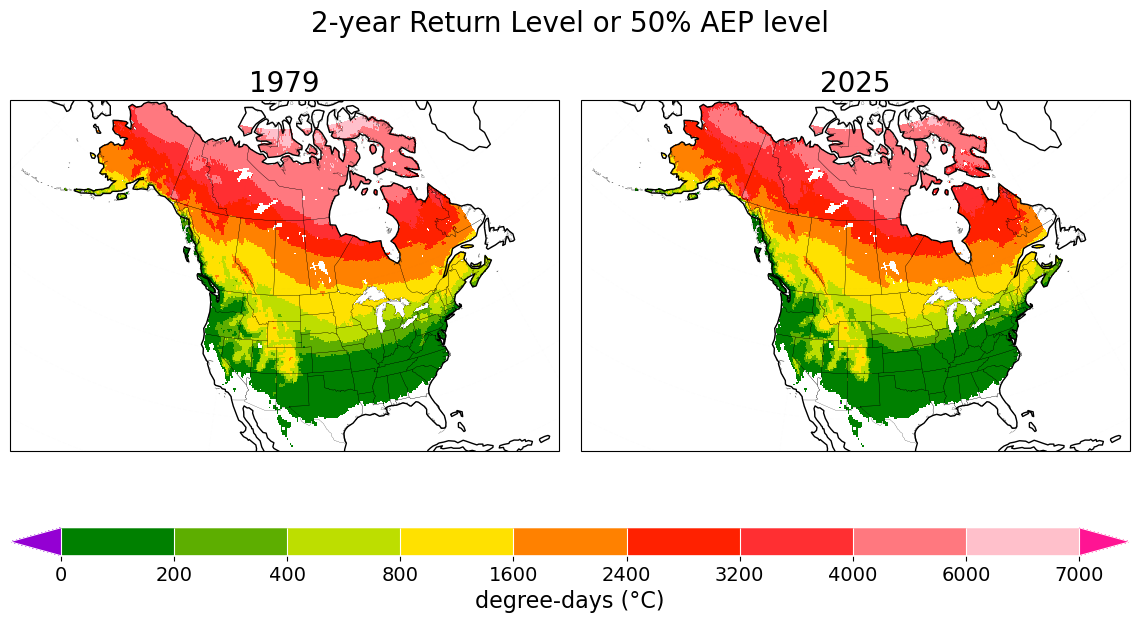

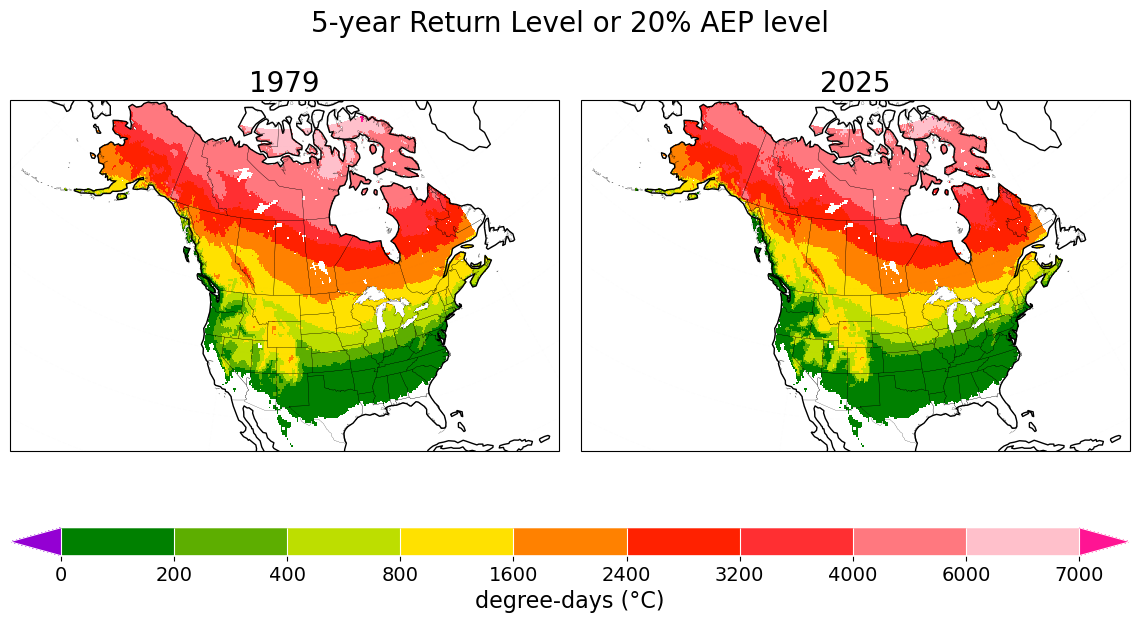

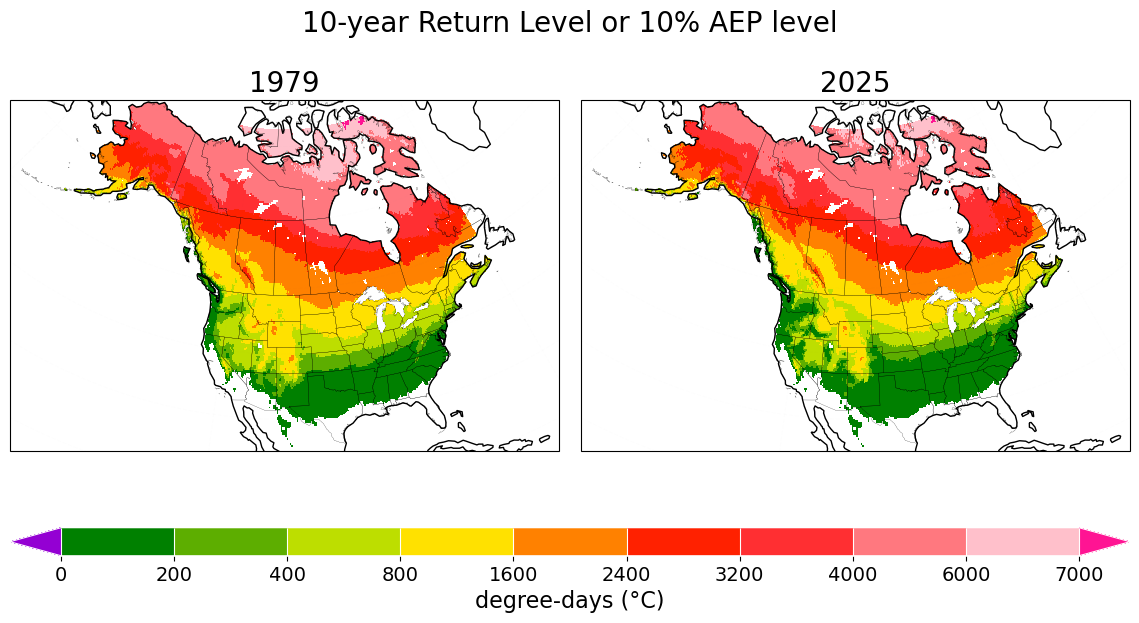

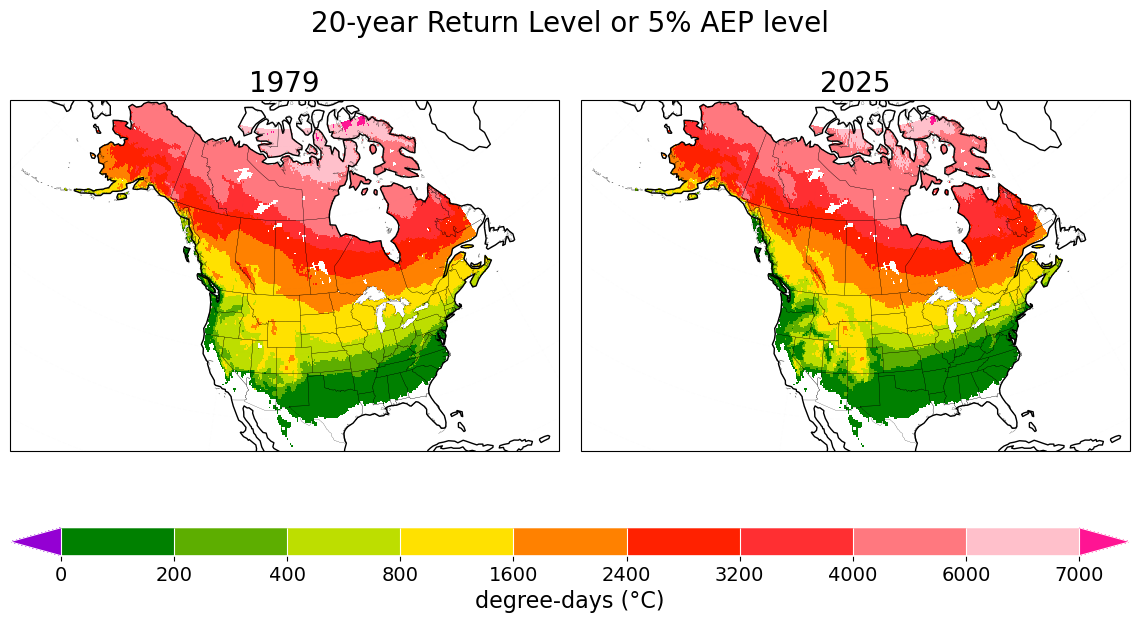

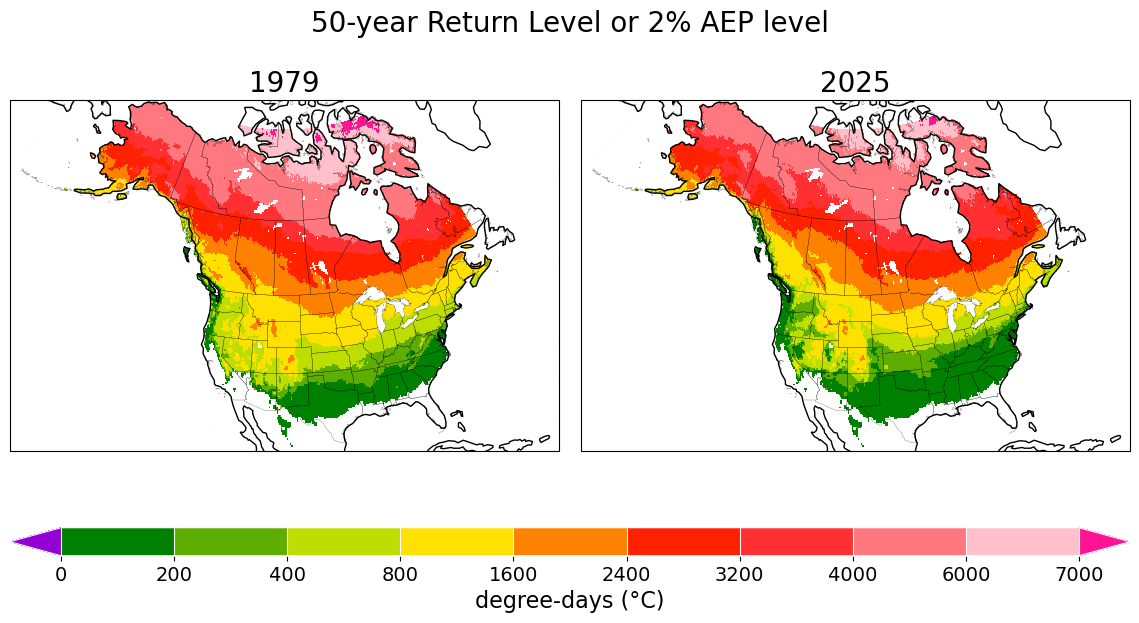

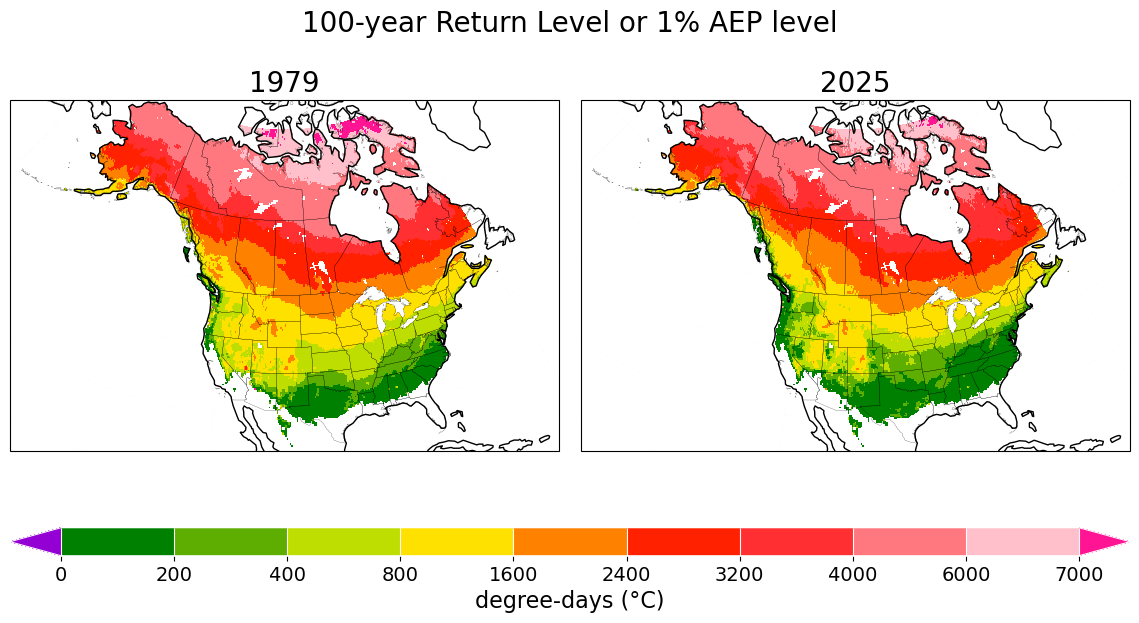

In [59]:

proj=ccrs.PlateCarree()
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(0,6800,800)
clevs = np.concat([np.arange(0,600,200), np.arange(800,4800,800), np.arange(6000,8000,1000)])
cmap=cmapI
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})

  plt.subplots_adjust(bottom=0.3,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
  ax = ax.flatten()
  for ix in range(0,len(Tyears)):
    cc = rl.isel(return_periods=irp).sel(time=Tyears[ix]).\
    plot.pcolormesh(ax=ax[ix],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax[ix].set_title(f'{Tyears[ix]}',fontsize=20)  
  ##
  for ix in range(0,len(ax)):
    ####
    grd = ax[ix].gridlines(
      draw_labels=False, 
      color='gray', alpha=0.01, linestyle='--')
    grd.top_labels = False   # Disable top labels
    grd.right_labels = False # Disable right labels. 
    ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
    ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
    ax[ix].coastlines()

  #
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])

  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both')
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'{units}',fontsize=16)  
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)
  # create a second axes instance and set the limits you need
  #cax2 = cbar.ax.twiny()
  #cax2.set_xlim(cbar.ax.get_xlim()) 
  #cax2.set_xlabel('degree-days (°F)',fontsize=16)
  # move ticks and label of colorbar to the left
  #c_ticks = cbar.ax.get_xticks()
  #cax2.set_xticks(c_ticks)
  #cax2.set_xticklabels([f'{t*1.8:.0f}' for t in c_ticks],fontsize=14)

  plt.suptitle(f'{return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  

*Return-level maps:
These panels show the estimated return level for selected return periods at two reference years (1979, 2025), illustrating how the intensity of extreme events varies geographically.*


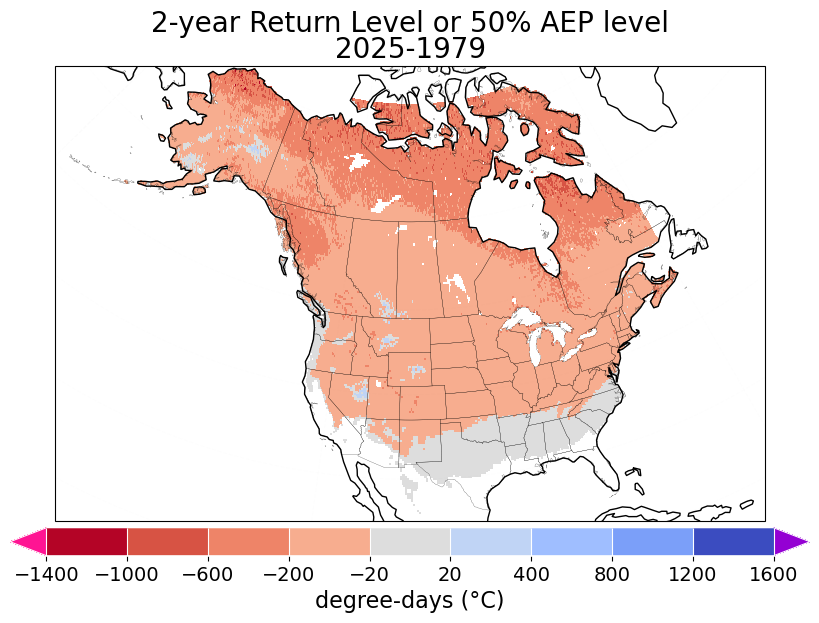

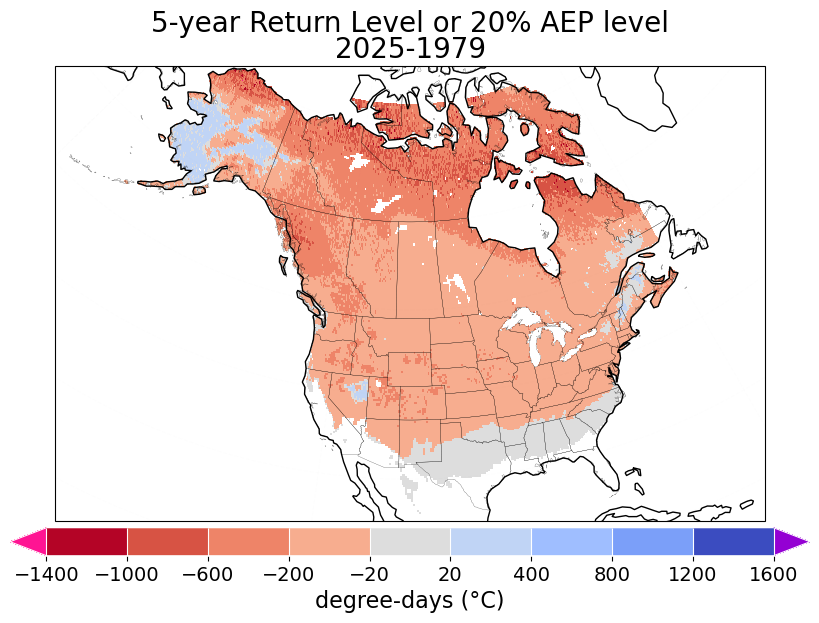

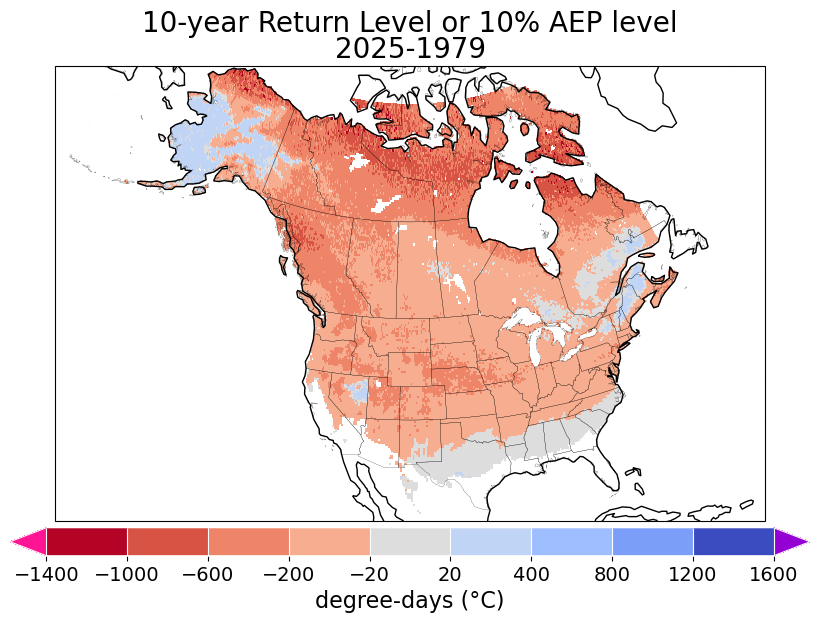

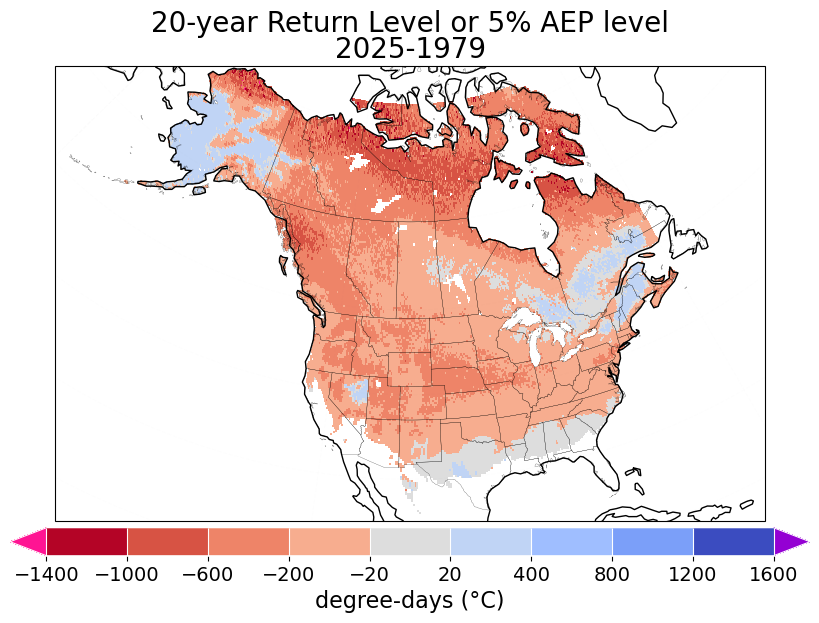

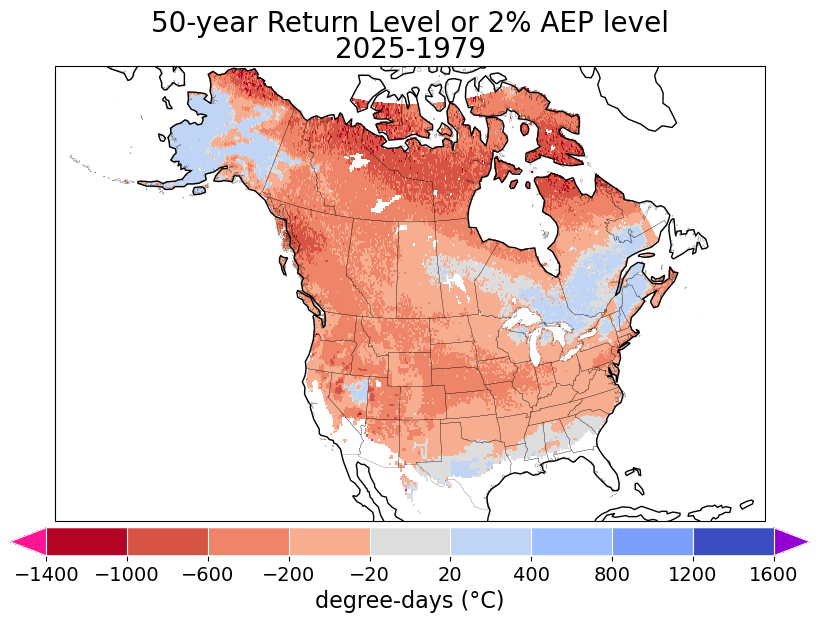

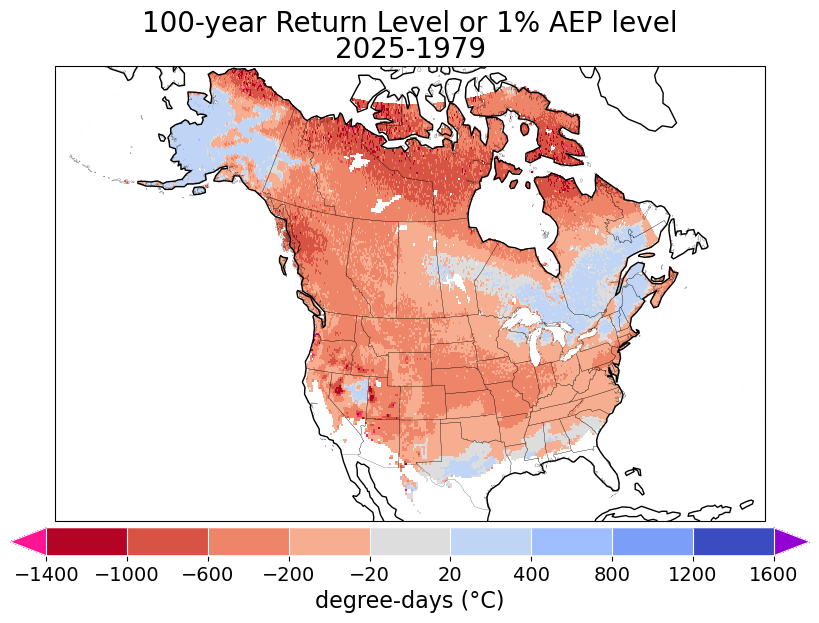

In [44]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-1400,1800,400)
clevs= np.concatenate((np.arange(-1400,0,400),[-20,20] ,np.arange(400,1800,400)))
cmap = cm.get_cmap(cmapAr,len(clevs)+1)
cmap.set_under('deeppink')
cmap.set_over('darkviolet')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)#mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])

for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,7),subplot_kw={'projection':proj})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

  cc = (rl.isel(return_periods=irp).sel(time=Tyears[-1])-rl.isel(return_periods=irp).sel(time=Tyears[0])).\
    plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
  ax.set_title(f'{Tyears[-1]}-{Tyears[0]}',fontsize=20)  
  ##

  ####
  grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax.set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax.coastlines()

  #
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',extend='both',drawedges=True)
  cbar.set_ticks(clevs[:])
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'{units}',fontsize=16)  
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)

  plt.suptitle(f'{return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20) 

*Change between two time periods:
These maps show the difference in return level between the end and start of the record, helping to visualize temporal change in the extreme-value field.*


In [55]:

## Build colorbar
from matplotlib import cm
clevsa=np.arange(0.05,1.01,0.01)
clevsb=np.arange(0,0.05,0.001)
clevs_pv=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = mcolors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

Text(0.5, 0.98, 'p-value Non Stationnary hypothesis')

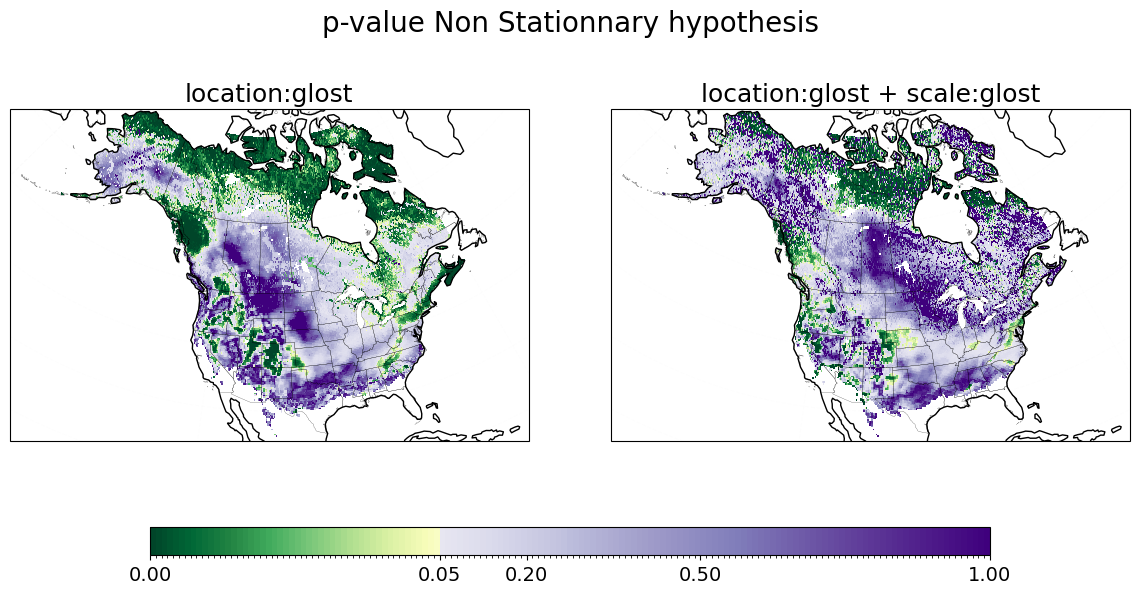

In [56]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.16)
ax = ax.flatten()
cc = pvalueL.plot.pcolormesh(ax=ax[0],cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(f'location:glost',fontsize=18)  
cc = pvalueS.plot.pcolormesh(ax=ax[1],cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(f'location:glost + scale:glost',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=[0,0.05,0.2,0.5,1])
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

plt.suptitle(f'p-value Non Stationnary hypothesis',fontsize=20)  

*P-value maps for non-stationarity tests (location and scale). Green shading identifies regions where the mean p-value is less than 0.05, indicating statistically significant non-stationarity at the 95% confidence level. Lower p-values reflect stronger evidence for rejecting the stationary-hypothesis null.*

Text(0.5, 0.98, 'Location parameter')

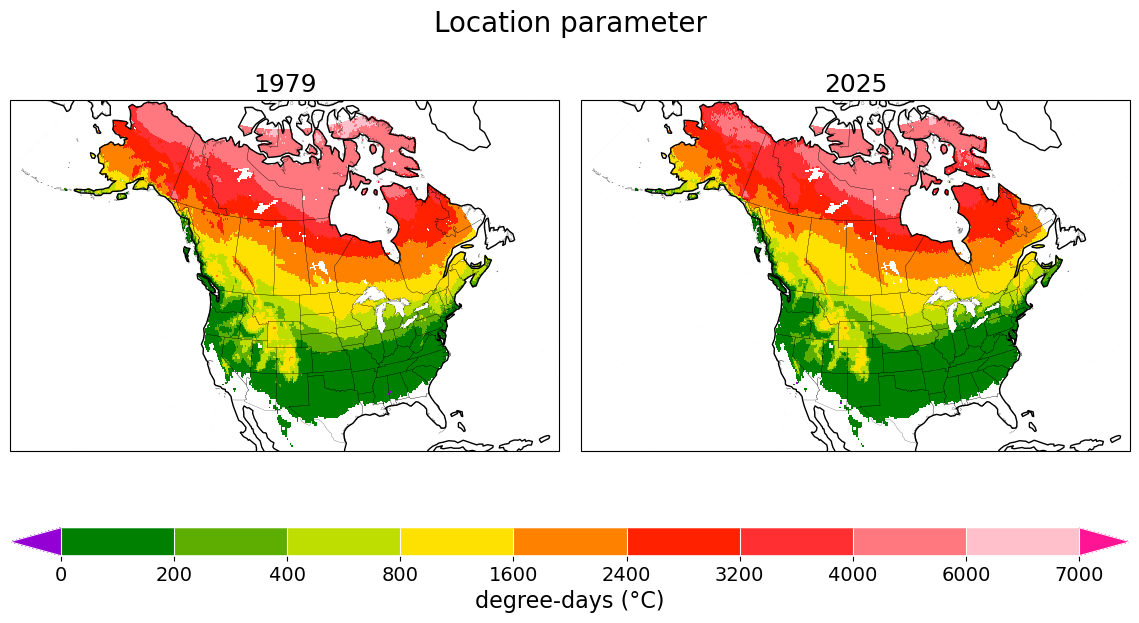

In [62]:
clevs=np.arange(0,6800,800)
clevs = np.concat([np.arange(0,600,200), np.arange(800,4800,800), np.arange(6000,8000,1000)])
cmap=plt.get_cmap(cmapI,len(clevs)).copy()
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.3,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
cc = location.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
location.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[:],drawedges=True,extend='both')
cbar.set_label(label=units,fontsize=16)
cbar.ax.tick_params(labelsize=14)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Location parameter')

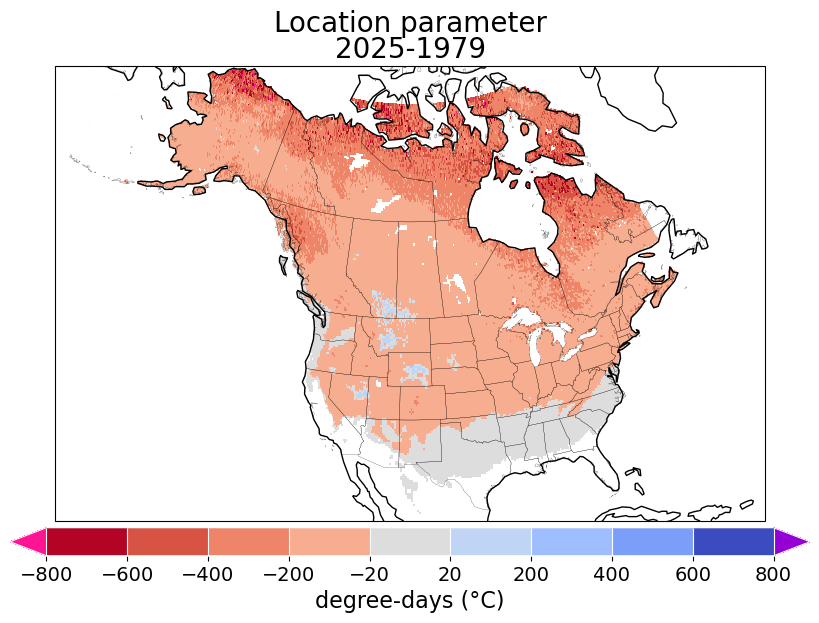

In [64]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs= np.concatenate((np.arange(-800,0,200),[-20,20] ,np.arange(200,1000,200)))
cmap = cm.get_cmap(cmapAr,len(clevs)+1)
cmap.set_under('deeppink')
cmap.set_over('darkviolet')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

cc = (location.sel(time=Tyears[-1])-location.sel(time=Tyears[0])).\
  plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
ax.set_title(f'{Tyears[-1]}-{Tyears[0]}',fontsize=20)  
##

####
grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lonW,lonE,latS,latN), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()

#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',extend='both',drawedges=True)
cbar.set_ticks(clevs[:])
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Scale parameter')

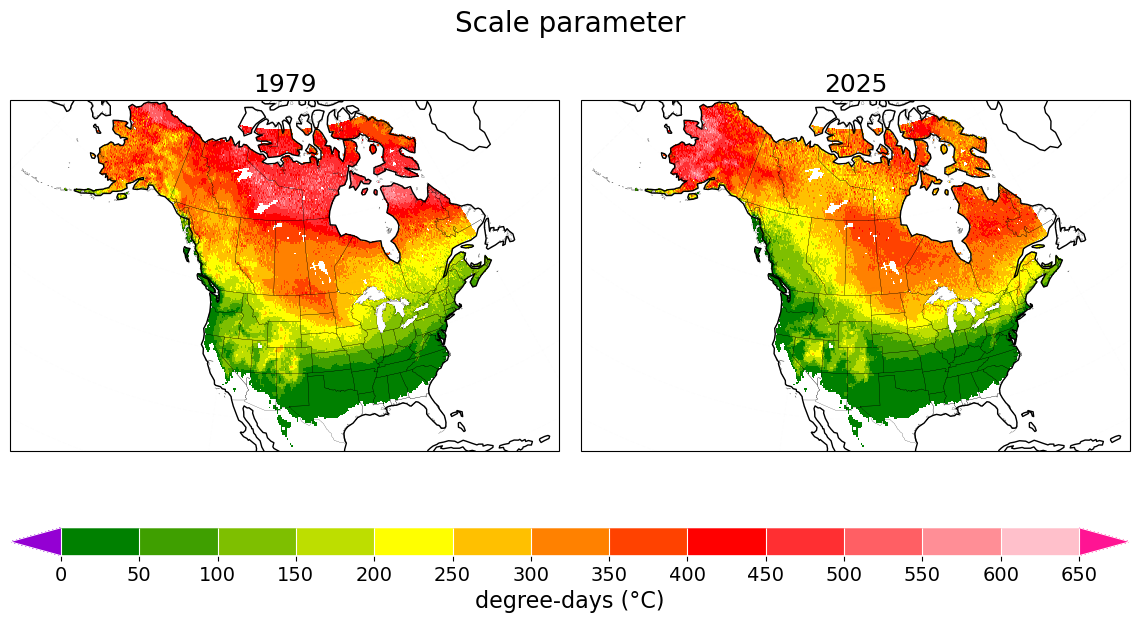

In [65]:
clevs = np.arange(0,700,50)
cmap = plt.get_cmap(cmapI,len(clevs)).copy()
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.3,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
cc = scale.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
scale.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[:],drawedges=True,extend='both')
cbar.set_label(label=units,fontsize=16)
cbar.ax.tick_params(labelsize=14)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Scale parameter',fontsize=20)  

Text(0.5, 0.98, 'Shape parameter')

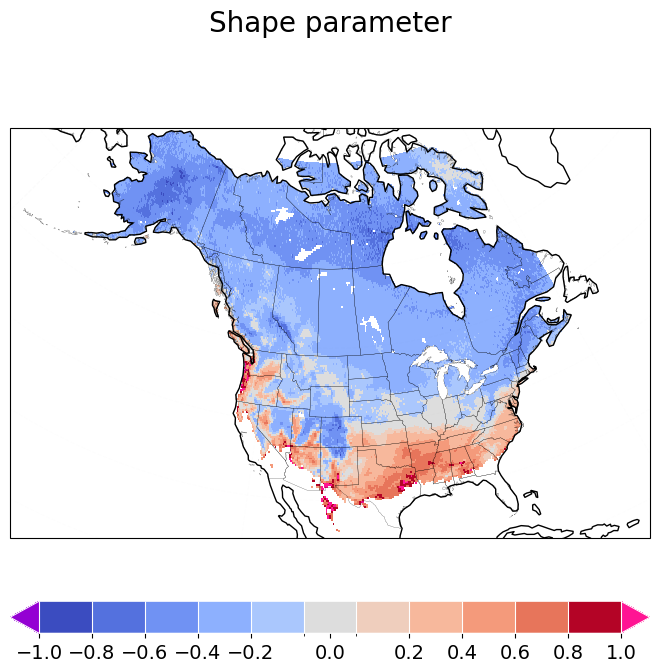

In [69]:
clevst = np.arange(-1,1.2,0.2)

clevs= np.concatenate((np.arange(-1,0,0.2),[-0.1,0.1] ,np.arange(0.2,1.2,0.2)))
cmap = cm.get_cmap(cmapA,len(clevs)+1)
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = shape.sel(time=yeare).plot.pcolormesh(ax=ax,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
ax.set_title('',fontsize=18) 
####

####
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lonW,lonE,latS,latN), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
#
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevst[:],drawedges=True,extend='both')
cbar.ax.tick_params(labelsize=14)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Shape parameter',fontsize=20)  

*Parameter maps (location/scale/shape): Spatial maps of fitted GEV parameters at the selected years (1979,2025), with difference maps for the change between those years.*

Text(0.5, 0.98, 'Tests averaged in Time')

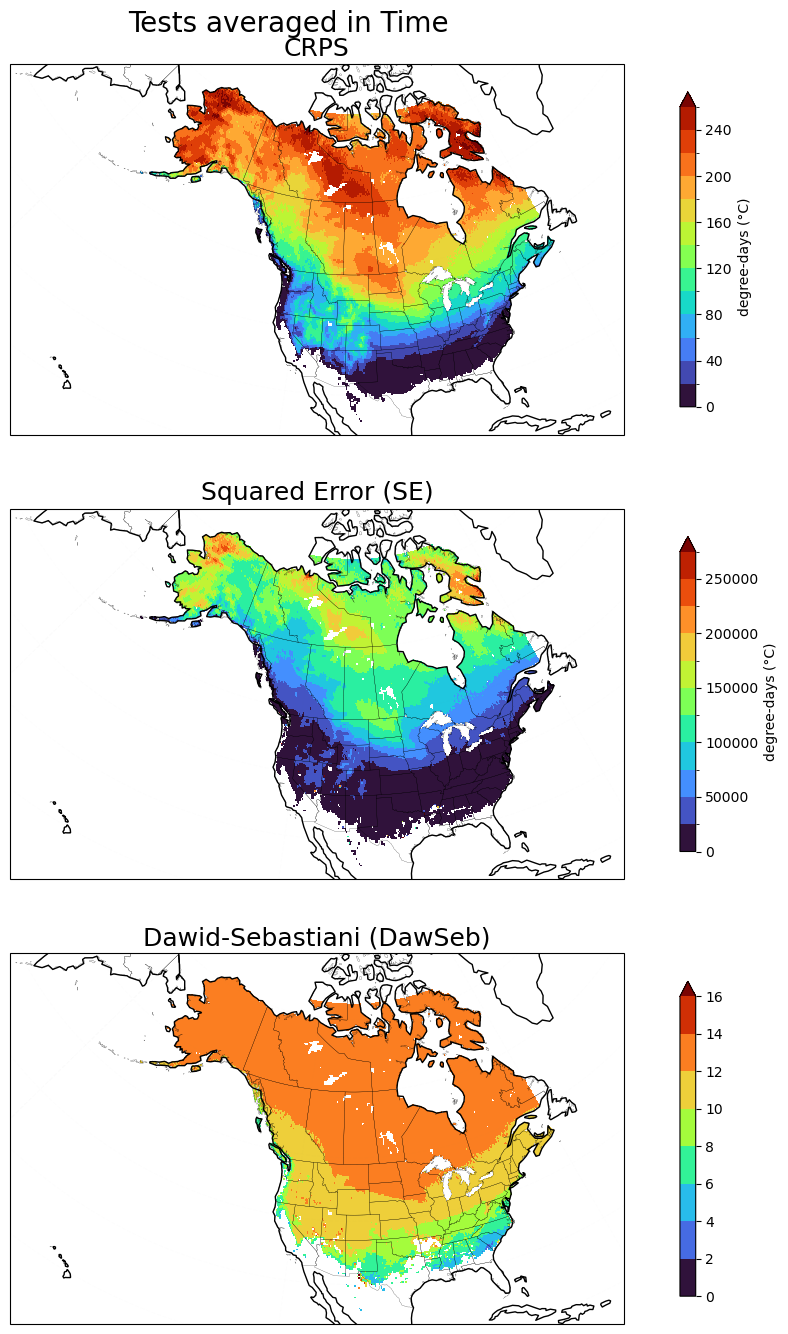

In [70]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(14,18),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.2,wspace=0.02)

ax = ax.flatten()
clevs = np.arange(0,280,20)
cc = CRPS_cv.mean('time').plot.pcolormesh(ax=ax[0],cmap='turbo',levels=clevs,transform=ccrs.PlateCarree(),cbar_kwargs={'shrink':0.85,'label':units})
ax[0].set_title(f'CRPS',fontsize=18)  
clevs = np.arange(0,300000,25000)
cc = SE_cv.mean('time').plot.pcolormesh(ax=ax[1],cmap='turbo',levels=clevs,transform=ccrs.PlateCarree(),cbar_kwargs={'shrink':0.85,'label':units})
ax[1].set_title(f'Squared Error (SE)',fontsize=18)  
clevs = np.arange(0,18,2)
cc = DawSeb_cv.mean('time').plot.pcolormesh(ax=ax[2],cmap='turbo',levels=clevs,transform=ccrs.PlateCarree(),cbar_kwargs={'shrink':0.85,'label':''})
ax[2].set_title(f'Dawid-Sebastiani (DawSeb)',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#

plt.suptitle(f'Tests averaged in Time',fontsize=20)  

*Diagnostics (CRPS / SE / Dawid–Sebastiani): Time-averaged diagnostic maps that assess predictive performance; see Technical details for scoring definitions.*

Text(0.5, 0.98, 'Tests averaged in Time')

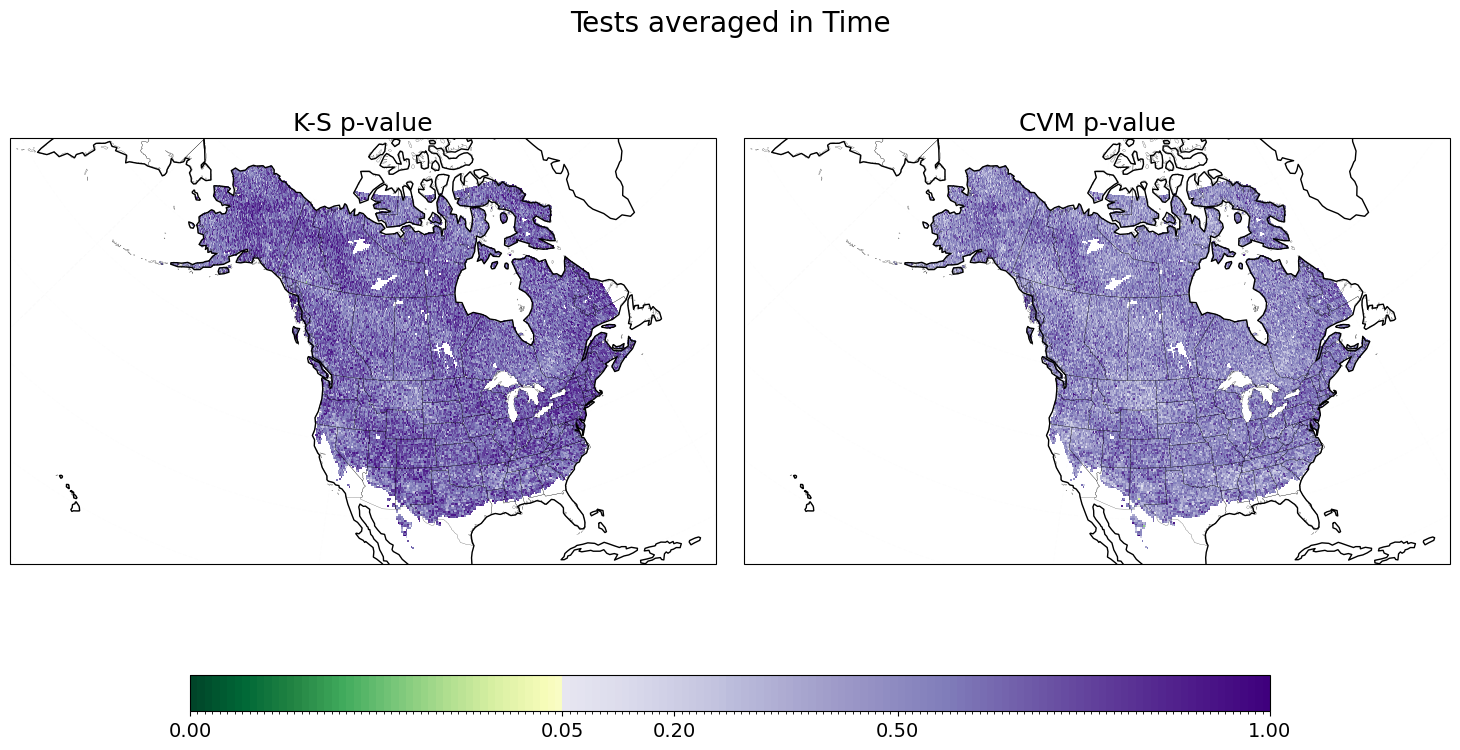

In [71]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(18,9),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.04)
ax = ax.flatten()
cc = KS_pvalue_cv.mean('time').plot.pcolormesh(ax=ax[0],cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(f'K-S p-value',fontsize=18)  
cc = CVM_pvalue_cv.mean('time').plot.pcolormesh(ax=ax[1],cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(f'CVM p-value',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=[0,0.05,0.2,0.5,1])
cbar.ax.tick_params(labelsize=14)   
#
plt.suptitle(f'Tests averaged in Time',fontsize=20)  

*Time-averaged p-value maps from the Kolmogorov–Smirnov (K–S) and Cramér–von Mises (CvM) goodness-of-fit tests. Regions shaded in green indicate p-values < 0.05, corresponding to rejection of the null hypothesis at the 95% significance level and suggesting inadequate model fit. Regions shaded in purple indicate p-values > 0.05, indicating no significant evidence against the fitted distribution. The color scale represents the magnitude of the p-values, with lower values reflecting stronger departures from the assumed model.*

In [72]:
Tquantile=['0.95','0.05']
vq=[float(x) for x in Tquantile]

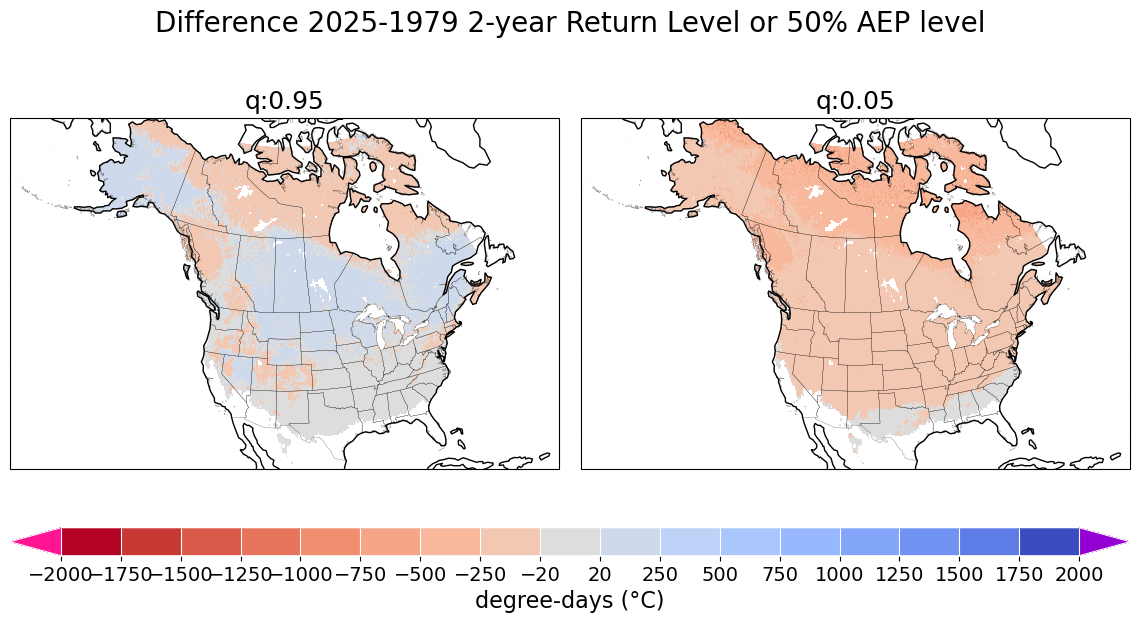

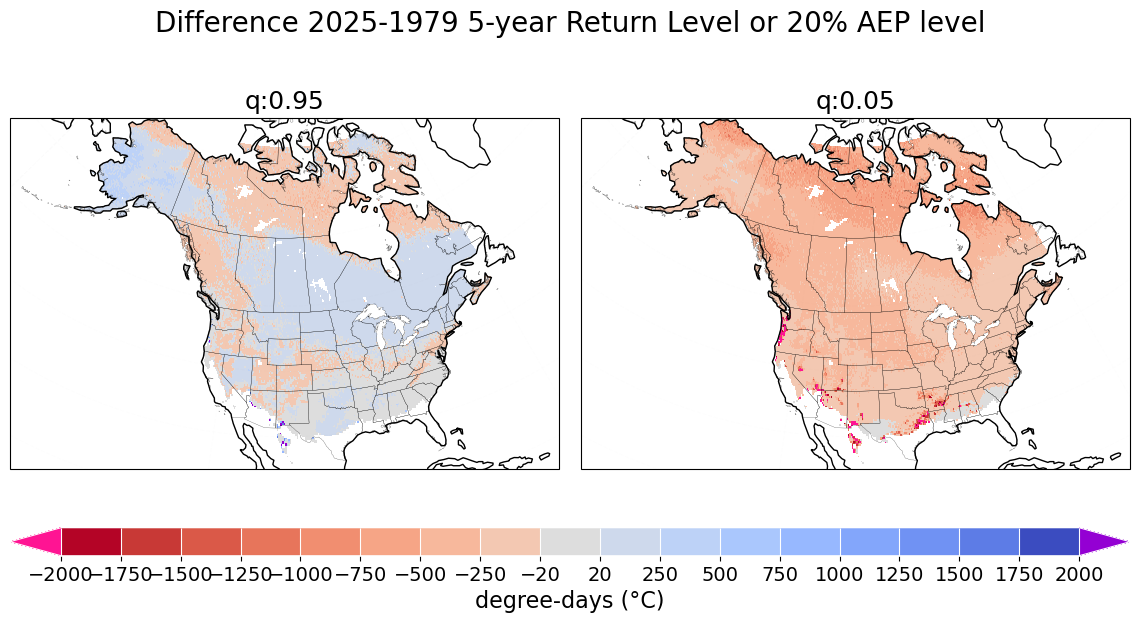

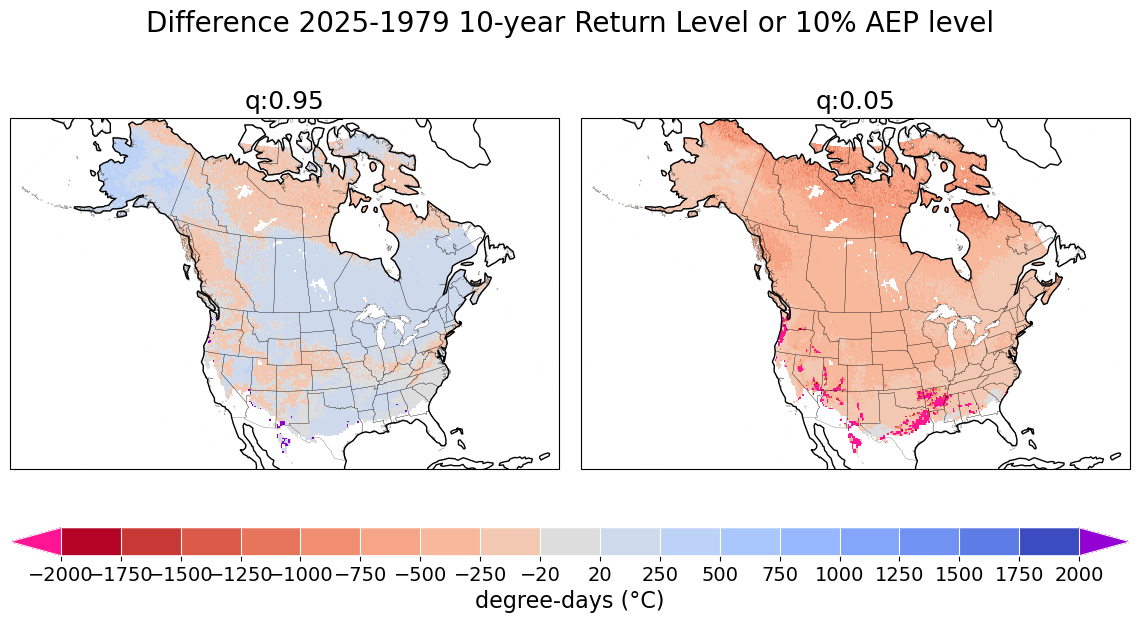

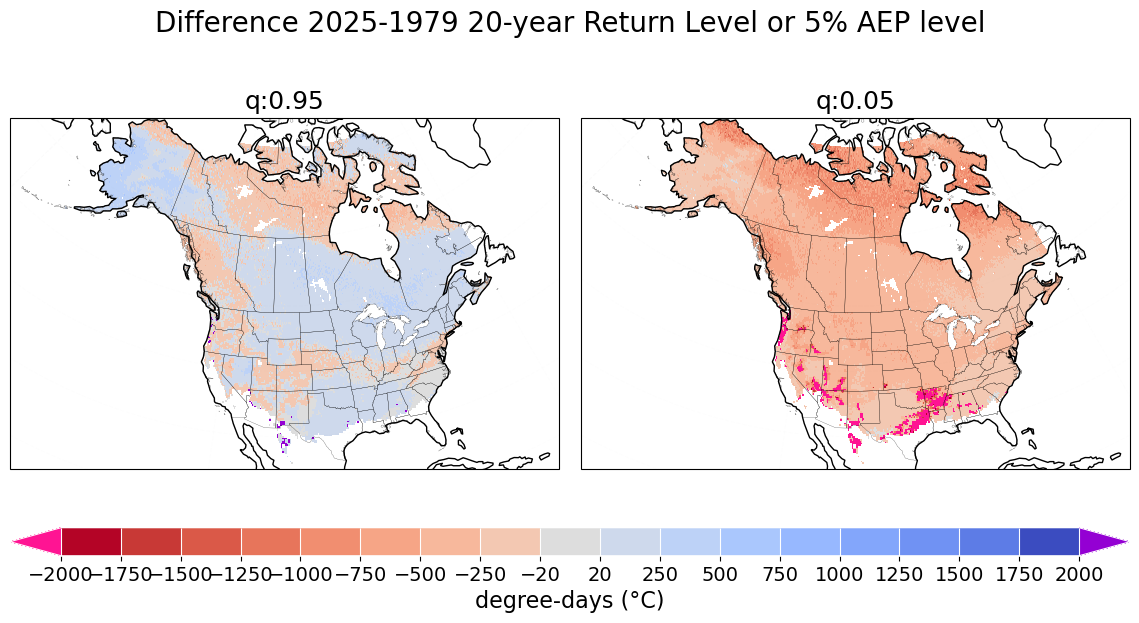

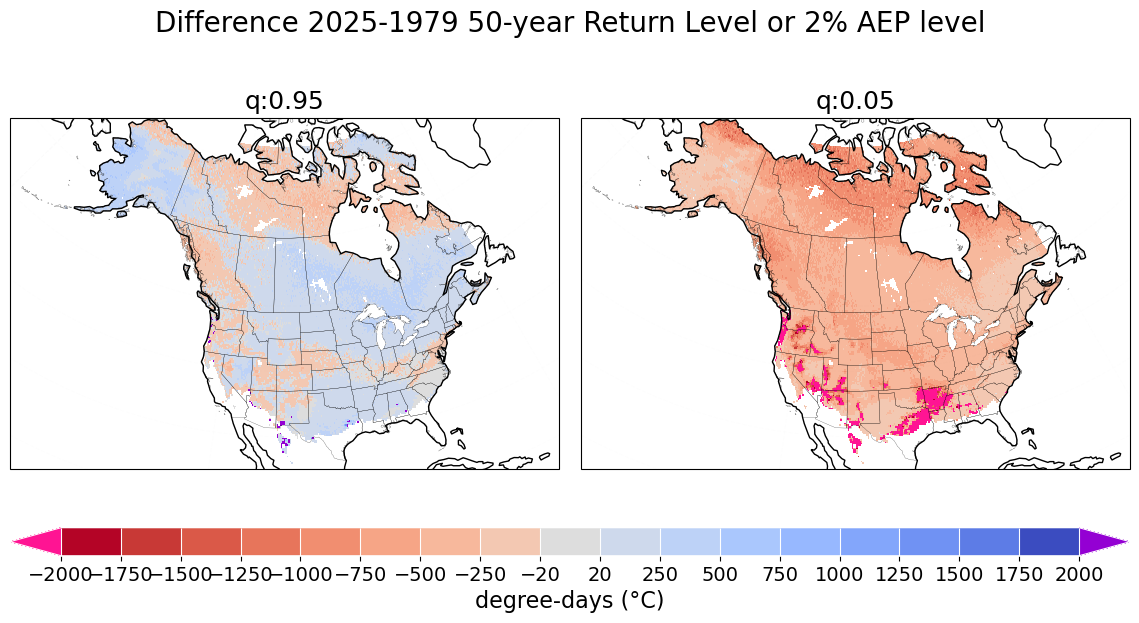

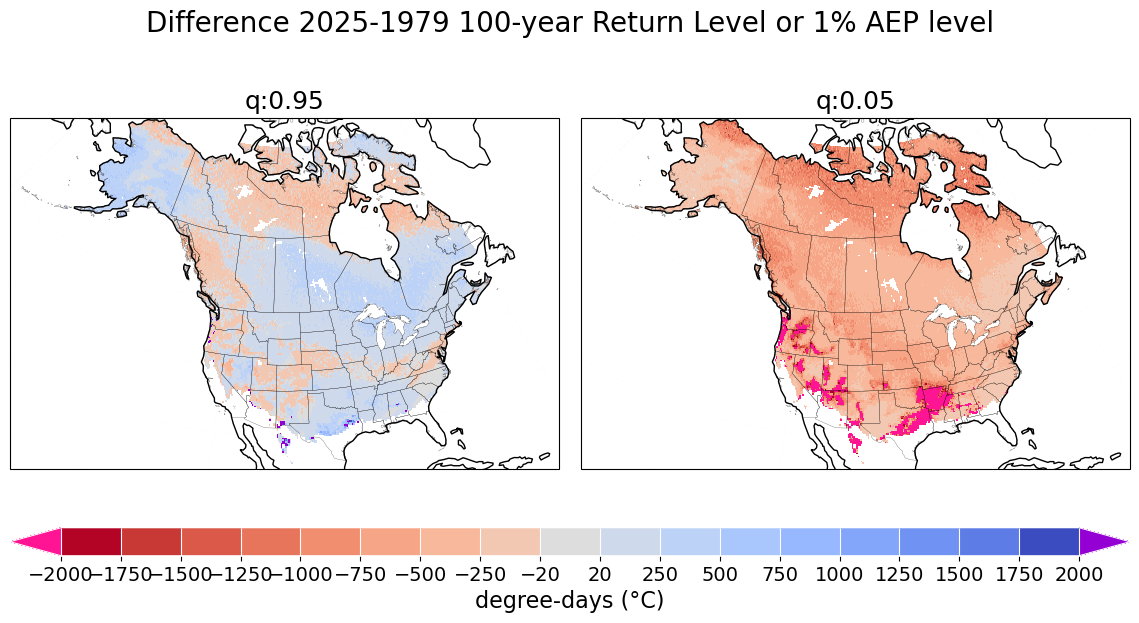

In [75]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-2000,2500,500)
clevst=np.arange(-2000,2250,250)

clevs= np.concatenate((np.arange(-2000,0,250),[-20,20] ,np.arange(250,2250,250)))
cmap = cm.get_cmap(cmapAr,len(clevs)+1)
cmap.set_under('deeppink')
cmap.set_over('darkviolet')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=1,ncols=len(Tquantile),figsize=(14,7),subplot_kw={'projection':proj})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

  for ix in range(0,len(Tquantile)):
    cc = Diffrl_q.sel(quantile=vq[ix]).isel(return_periods=irp).plot.pcolormesh\
    (ax=ax[ix],transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
    ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
    ##

    ####
    grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
    grd.top_labels = False   # Disable top labels
    grd.right_labels = False # Disable right labels. 
    ax[ix].set_extent((lonW,lonE,latS,latN), crs=proj_data)
    ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
    ax[ix].coastlines()

  #
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',extend='both', drawedges=True)
  cbar.set_ticks(clevs[:])
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'{units}',fontsize=16)
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)

  plt.suptitle(f'Difference {yeare}-{yearb} {return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  

*Spatial patterns of change in the lower (q=0.05) and upper (q=0.95) quantiles between the start (1979) and end (2025) period.*

## Step 4: Technical notes

### Scoring formulas

- CRPS for predictive CDF $F$ and observation $y$:

  $$\mathrm{CRPS}(F,y)=\int_{-\infty}^{\infty}(F(x)-\mathbf{1}_{\{x\ge y\}})^2\,dx.$$

- Squared Error (SE):

  $$\mathrm{SE}=(y-\mu)^2.$$

- Dawid–Sebastiani Score (DSS):

  $$\mathrm{DSS}=\frac{(y-\mu)^2}{\sigma^2}+2\log\sigma.$$
